# ek_freq_eda
FFT-based period detection · decomposition · anomaly overlay

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd drive/MyDrive/Colab Notebooks/sentinel
!pip install -e .

import sys
sys.path.insert(0, "/content/drive/MyDrive/Colab Notebooks/sentinel/src")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/sentinel
Obtaining file:///content/drive/MyDrive/Colab%20Notebooks/sentinel
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sentinel (pyproject.toml) ... done
  Created wheel for sentinel: filename=sentinel-0.1.0-0.editable-py3-none-any.whl size=1253 sha256=5d9e76f8dc61d21eeb638ef55d37b7e435426df689e58c31e398ea4b5b5491f1
  Stored in directory: /tmp/pip-ephem-wheel-cache-5u6co1n1/wheels/0b/1f/c3/dfb5498defd946b02a9af16aa08b88f67e91903544aef346c4
Successfully built sentinel
  Attempting uninstall: sentinel
    Found existing installation: sentinel 0.1.0
    Uninstalling sentinel-0.1.0:
      Successfully uninstalled sentinel-0.1.0


In [2]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from sentinel.ml_logic.data import find_anomaly_segments
import json
from pathlib import Path

In [3]:
# ── config ───────────────────────────────────────────────────────────────────
CHANNELS = [
    'channel_41', 'channel_42', 'channel_43',
    'channel_44', 'channel_45', 'channel_46',
]
DECOMP_CH       = CHANNELS[0]   # channel shown in 4-panel decomposition
DS_FACTOR       = 10            # downsample factor for FFT
MAX_PERIOD      = 3_000_000     # upper cap for big-period search (avoids red-noise artifact)
ZOOM_LEN        = 15_000        # rows in short-scale zoom
ZOOM_START_FRAC = 0.35          # position of zoom (fraction of nominal rows)

BIG_WINDOW      = 50_000        # uniform_filter size for big-trend extraction (config constant)

ANOMALY_COLOR = '#e74c3c'
NOMINAL_COLOR = '#2980b9'

RAW_DIR = Path('./data/raw')
OUT_DIR = Path('./data')

In [4]:
cols  = ['id', 'is_anomaly'] + CHANNELS
train = pq.read_table(str(RAW_DIR / 'train.parquet'), columns=cols
                      ).to_pandas().set_index('id')
print(f'Loaded {len(train):,} rows')
print(f'Anomaly rate: {train["is_anomaly"].mean():.4%}')

nom = train[train['is_anomaly'] == 0]
print(f'Nominal rows: {len(nom):,}')

Loaded 14,728,321 rows
Anomaly rate: 10.4839%
Nominal rows: 13,184,217


In [5]:
def find_periods(series, n_peaks=2, min_period=50, max_period=None, ds_factor=10):
    """FFT on a downsampled version of series. Returns list of {period, power}."""
    x = series.values[::ds_factor].astype(np.float64)
    x -= x.mean()
    N     = len(x)
    freqs = np.fft.rfftfreq(N)                  # 0 … 0.5 cycles/sample
    power = np.abs(np.fft.rfft(x)) ** 2

    min_freq = 2.0 / N                           # need ≥ 2 full cycles visible
    if max_period is not None:
        min_freq = max(min_freq, ds_factor / max_period)
    max_freq = 1.0 / (min_period / ds_factor)
    search   = np.where((freqs > min_freq) & (freqs <= max_freq), power, 0.0)

    found = []
    for _ in range(n_peaks):
        idx = int(np.argmax(search))
        if search[idx] == 0:
            break
        period_orig = int(round(ds_factor / freqs[idx]))
        found.append({'period': period_orig, 'power': float(power[idx])})
        w = max(3, idx // 8)
        search[max(0, idx - w): idx + w + 1] = 0.0

    return sorted(found, key=lambda d: d['period'])

In [6]:
freq_map = {}
for ch in CHANNELS:
    raw_arr = nom[ch].values.astype(np.float64)

    # T_small: sharp high-freq peak — detectable directly on the raw signal
    p_small = find_periods(nom[ch], n_peaks=1, min_period=50, max_period=500,
                           ds_factor=DS_FACTOR)

    # T_medium: detrend first so the red-noise slope from the big sinusoid is removed,
    # making the ~2000-period peak visible above the local noise floor
    detrended = raw_arr - uniform_filter1d(raw_arr, size=BIG_WINDOW, mode='nearest')
    p_med = find_periods(pd.Series(detrended), n_peaks=1, min_period=500,
                         max_period=10_000, ds_factor=DS_FACTOR)

    T1 = p_small[0]['period'] if p_small else 98
    T2 = p_med[0]['period']   if p_med   else 2000
    freq_map[ch] = [T1, T2]
    print(f'{ch}: T_small={T1:,}  T_medium={T2:,}')

with open(OUT_DIR / 'freq_map.json', 'w') as f:
    json.dump(freq_map, f, indent=2)
print('\nSaved freq_map.json')

channel_41: T_small=98  T_medium=2,159
channel_42: T_small=98  T_medium=2,161
channel_43: T_small=98  T_medium=2,161
channel_44: T_small=98  T_medium=2,159
channel_45: T_small=98  T_medium=2,161
channel_46: T_small=98  T_medium=2,161

Saved freq_map.json


In [11]:
def decompose(arr, big_window, medium_window, small_window):
    """Three-level cascade decomposition with one refinement pass.

    Pass 1 (top-down): rough sin3 estimate via standard cascade.
    Pass 2: subtract sin3_rough from r1 so T1 doesn't contaminate sin2.

    Returns: sin1, sin2, sin3, res  (all same shape as arr)
    """
    a    = np.asarray(arr, dtype=np.float64)
    sin1 = uniform_filter1d(a,  size=big_window,    mode='nearest')
    r1   = a - sin1

    # pass 1 — rough estimates to isolate T1
    sin2_rough = uniform_filter1d(r1,              size=medium_window, mode='nearest')
    sin3_rough = uniform_filter1d(r1 - sin2_rough, size=small_window,  mode='nearest')

    # pass 2 — clean r1 of T1, then re-extract T2
    sin2 = uniform_filter1d(r1 - sin3_rough, size=medium_window, mode='nearest')
    r2   = r1 - sin2
    sin3 = uniform_filter1d(r2, size=small_window, mode='nearest')
    res  = r2 - sin3

    return sin1, sin2, sin3, res

## Viz — Power spectrum per channel

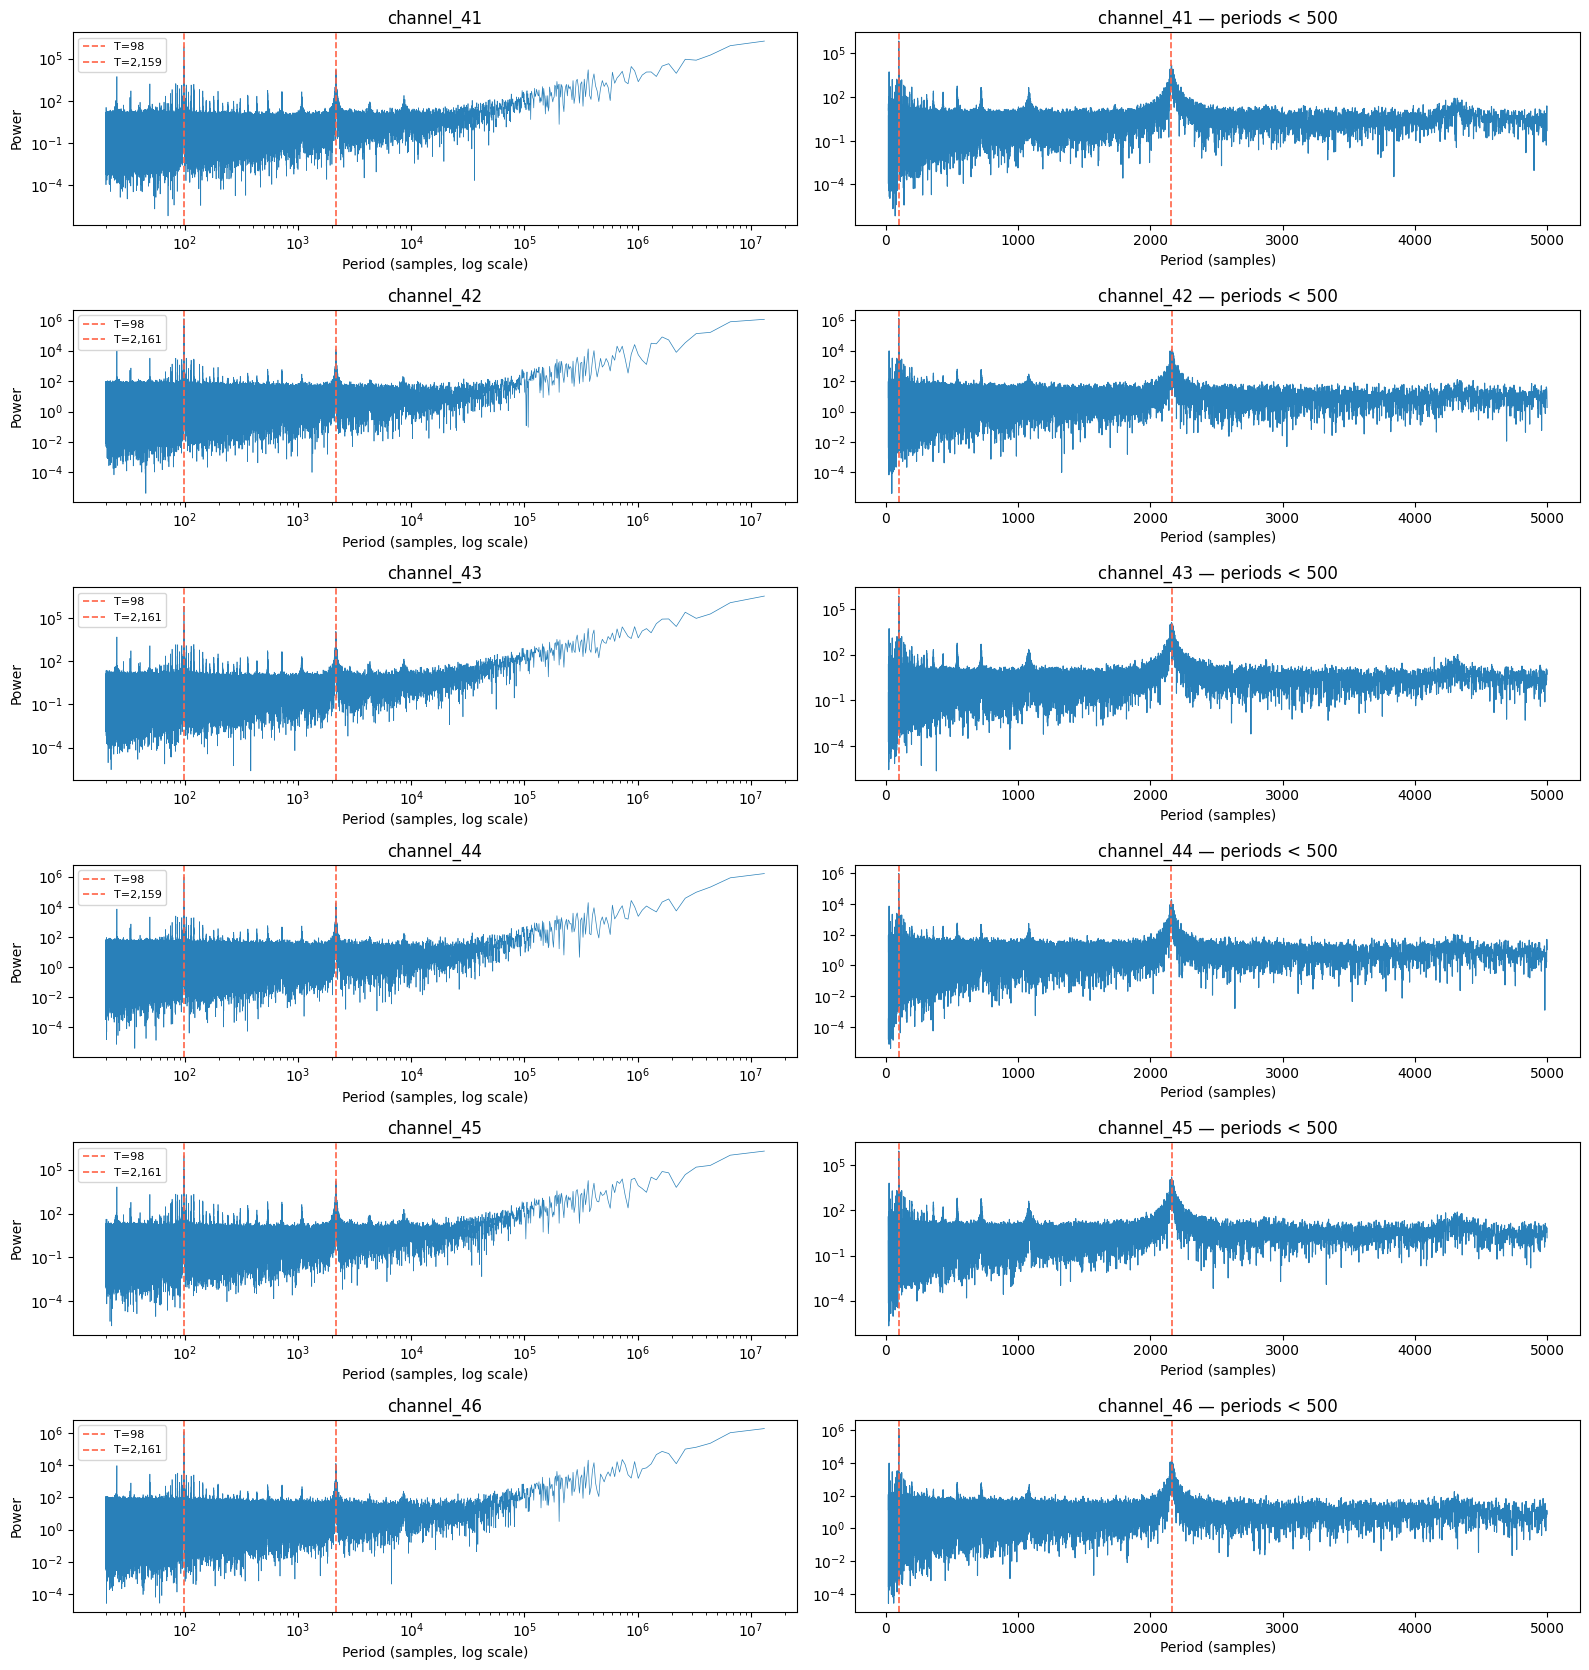

In [12]:
fig, axes = plt.subplots(len(CHANNELS), 2,
                         figsize=(16, 2.8 * len(CHANNELS)))
axes = axes.reshape(len(CHANNELS), 2)

for i, ch in enumerate(CHANNELS):
    x     = nom[ch].values[::DS_FACTOR].astype(np.float64)
    x    -= x.mean()
    freqs = np.fft.rfftfreq(len(x))
    power = np.abs(np.fft.rfft(x)) ** 2
    per_orig = DS_FACTOR / freqs[1:]
    pw       = power[1:]

    ax_l, ax_r = axes[i]

    # left: full log-log spectrum (shows 1/f slope and all peaks)
    ax_l.loglog(per_orig, pw, lw=0.5, color=NOMINAL_COLOR)
    ax_l.set_xlabel('Period (samples, log scale)')
    ax_l.set_ylabel('Power')
    ax_l.set_title(f'{ch}')

    # right: zoom on short periods to show the small sinusoid peak clearly
    mask = per_orig < 5000
    ax_r.semilogy(per_orig[mask], pw[mask], lw=0.8, color=NOMINAL_COLOR)
    ax_r.set_xlabel('Period (samples)')
    ax_r.set_title(f'{ch} — periods < 500')

    for p in freq_map.get(ch, []):
        for ax in (ax_l, ax_r):
            ax.axvline(p, color='tomato', ls='--', lw=1.2, label=f'T={p:,}')
    axes[i, 0].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'freq_eda_spectrum.png', dpi=100, bbox_inches='tight')
plt.show()

## Viz 4 — Signal decomposition (one channel)

T1=98  T2=2159  →  sw=19  mw=719  bw=50,000


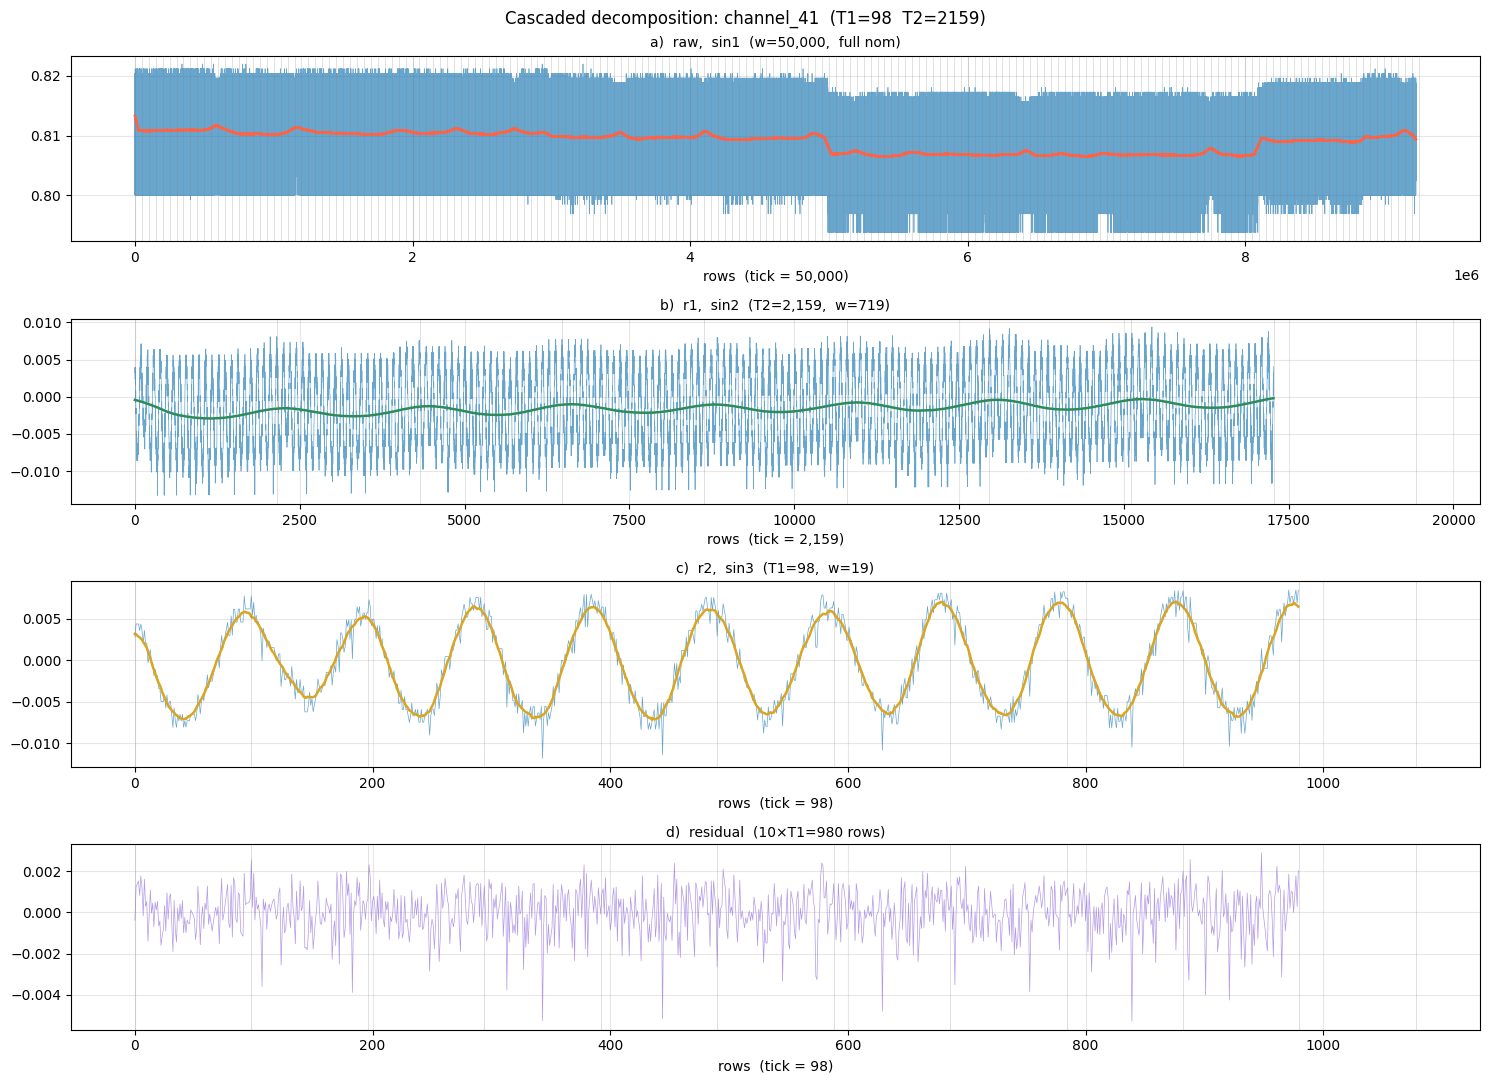

In [15]:
ch = DECOMP_CH
nom_start = int(len(nom) * 0.3)

T1, T2 = freq_map.get(ch, [98, 2000])
bw = BIG_WINDOW                       # config constant — period of big sin unknown from FFT
mw = max(T1 * 2, T2 // 3)             # isolates T2: passes T2, suppresses T1
sw = max(3, T1 // 5)                  # isolates T1

print(f'T1={T1}  T2={T2}  →  sw={sw}  mw={mw}  bw={bw:,}')

n_big     = len(nom) - nom_start   # всё с nom_start до конца nom
n_compute = n_big

seg_raw = nom[ch].values[nom_start: nom_start + n_compute].astype(np.float64)
sin1, sin2, sin3, res = decompose(seg_raw, bw, mw, sw)
r1 = seg_raw - sin1
r2 = r1      - sin2
r3 = r2      - sin3

n_med = min(8 * T2, n_compute)
n_sml = min(10 * T1, n_compute)

# (signal, overlay, title, color_base, color_comp, n_rows, tick_step)
panels = [
    (seg_raw[:n_big], sin1[:n_big],
     f'a)  raw,  sin1  (w={bw:,},  full nom)',
     NOMINAL_COLOR, 'tomato',    n_big, bw),
    (r1[:n_med],      sin2[:n_med],
     f'b)  r1,  sin2  (T2={T2:,},  w={mw})',
     NOMINAL_COLOR, 'seagreen',  n_med, T2),
    (r2[:n_sml],      sin3[:n_sml],
     f'c)  r2,  sin3  (T1={T1},  w={sw})',
     NOMINAL_COLOR, 'goldenrod', n_sml, T1),
    (r3[:n_sml],      None,
     f'd)  residual  (10×T1={10*T1} rows)',
     'mediumpurple', None,       n_sml, T1),
]

fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=False)
for ax, (base, comp, title, c_base, c_comp, n, tick_step) in zip(axes, panels):
    xs = np.arange(n)
    ax.plot(xs, base, lw=0.5, alpha=0.7, color=c_base)
    if comp is not None:
        ax.plot(xs, comp, lw=1.8, color=c_comp)
    for k in range(n // tick_step + 2):
        ax.axvline(k * tick_step, color='gray', lw=0.5, alpha=0.35)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(f'rows  (tick = {tick_step:,})')
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Cascaded decomposition: {ch}  (T1={T1}  T2={T2})', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'freq_eda_decomp.png', dpi=100, bbox_inches='tight')
plt.show()